
# FEM with Lagrange Polynomials: Linear vs Cubic Interpolation

This notebook contains two examples:

1. $-u''=\cos(\pi x)$ with $u(0)=u(1)=0$
2. 1-D heat conduction with internal heat generation, $T(0)=100^\circ$C, and convection at $x=L$

For each problem we compare:
- three 2-node linear elements
- one 4-node cubic Lagrange element

**Please note All Lagrange basis functions are defined directly in the physical coordinate $x$.**


In [1]:

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = sp.symbols('x')

def lagrange_basis(x, nodes, i):
    N = 1
    for j in range(len(nodes)):
        if j != i:
            N = N * (x - nodes[j]) / (nodes[i] - nodes[j])
    return N



# Problem 1:

$$-u''= \cos(\pi x)$$

Weak form:

$$
\int_0^1 u'v'\,dx
=
\int_0^1 \cos(\pi x)v\,dx
$$

Use four uniform nodes:

$$
x=\left[0,\frac13,\frac23,1\right].
$$


In [2]:

# -----------------------------
# Three linear elements
# -----------------------------

nodes = np.array([0.0, 1/3, 2/3, 1.0])

connectivity = [
    [0, 1],
    [1, 2],
    [2, 3]
]

K_global = np.zeros((4,4))
F_global = np.zeros(4)

for e in range(3):

    node1, node2 = connectivity[e]

    x1 = nodes[node1]
    x2 = nodes[node2]

    local_nodes = [x1, x2]

    N = [
        sp.simplify(lagrange_basis(x, local_nodes, 0)),
        sp.simplify(lagrange_basis(x, local_nodes, 1))
    ]

    Ke = np.zeros((2,2))
    Fe = np.zeros(2)

    for i in range(2):

        for j in range(2):

            Ke[i,j] = float(
                sp.integrate(
                    sp.diff(N[i],x)*sp.diff(N[j],x),
                    (x,x1,x2)
                )
            )

        Fe[i] = float(
            sp.integrate(
                N[i]*sp.cos(sp.pi*x),
                (x,x1,x2)
            )
        )

    print("\nElement", e+1)
    print("Ke =")
    print(Ke)
    print("Fe =")
    print(Fe)

    dofs = connectivity[e]

    for i in range(2):
        I = dofs[i]
        F_global[I] += Fe[i]

        for j in range(2):
            J = dofs[j]
            K_global[I,J] += Ke[i,j]

    print("Global K after assembly:")
    print(K_global)

print("\nFinal global K:")
print(K_global)

print("\nFinal global F:")
print(F_global)



Element 1
Ke =
[[ 3. -3.]
 [-3.  3.]]
Fe =
[0.15198178 0.12368267]
Global K after assembly:
[[ 3. -3.  0.  0.]
 [-3.  3.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]]

Element 2
Ke =
[[ 3. -3.]
 [-3.  3.]]
Fe =
[ 0.0282991 -0.0282991]
Global K after assembly:
[[ 3. -3.  0.  0.]
 [-3.  6. -3.  0.]
 [ 0. -3.  3.  0.]
 [ 0.  0.  0.  0.]]

Element 3
Ke =
[[ 3. -3.]
 [-3.  3.]]
Fe =
[-0.12368267 -0.15198178]
Global K after assembly:
[[ 3. -3.  0.  0.]
 [-3.  6. -3.  0.]
 [ 0. -3.  6. -3.]
 [ 0.  0. -3.  3.]]

Final global K:
[[ 3. -3.  0.  0.]
 [-3.  6. -3.  0.]
 [ 0. -3.  6. -3.]
 [ 0.  0. -3.  3.]]

Final global F:
[ 0.15198178  0.15198178 -0.15198178 -0.15198178]


In [16]:

# -----------------------------
# Apply u1 = 0 and u4 = 0
# directly to the full 4x4 system
# -----------------------------

K_bc = K_global.copy()
F_bc = F_global.copy()

# u1 = 0
K_bc[0,:] = 0.0
K_bc[:,0] = 0.0
K_bc[0,0] = 1.0
F_bc[0] = 0.0

# u4 = 0
K_bc[3,:] = 0.0
K_bc[:,3] = 0.0
K_bc[3,3] = 1.0
F_bc[3] = 0.0

print("Final global K after boundary conditions:")
print(K_bc)

print("\nFinal global F after boundary conditions:")
print(F_bc)

U_linear = np.linalg.solve(K_bc,F_bc)

print("Linear FEM solution:")
for i in range(4):
    print(f"Node {i+1}: x = {nodes[i]:.6f}, u = {U_linear[i]:.8f}")


Final global K after boundary conditions:
[[ 1.  0.  0.  0.]
 [ 0.  6. -3.  0.]
 [ 0. -3.  6.  0.]
 [ 0.  0.  0.  1.]]

Final global F after boundary conditions:
[ 0.          0.15198178 -0.15198178  0.        ]
Linear FEM solution:
Node 1: x = 0.000000, u = 0.00000000
Node 2: x = 0.333333, u = 0.01688686
Node 3: x = 0.666667, u = -0.01688686
Node 4: x = 1.000000, u = 0.00000000


In [17]:

# Reconstruct piecewise-linear solution

x_linear_plot = []
u_linear_plot = []

for e in range(3):

    xa = nodes[e]
    xb = nodes[e+1]

    xe = np.linspace(xa,xb,100)

    local_nodes = [xa,xb]

    N1 = lagrange_basis(xe,local_nodes,0)
    N2 = lagrange_basis(xe,local_nodes,1)

    ue = N1*U_linear[e] + N2*U_linear[e+1]

    x_linear_plot.extend(xe)
    u_linear_plot.extend(ue)

x_linear_plot = np.array(x_linear_plot)
u_linear_plot = np.array(u_linear_plot)



## One 4-node cubic Lagrange element

The same four physical nodes are used, but now the whole interval is one element:

$$
u_h(x)=N_1u_1+N_2u_2+N_3u_3+N_4u_4.
$$


In [18]:

# -----------------------------
# One cubic element
# -----------------------------

cubic_nodes = nodes.copy()

N_cubic = []

for i in range(4):
    Ni = sp.simplify(lagrange_basis(x,cubic_nodes,i))
    N_cubic.append(Ni)

    print(f"N{i+1}(x) =")
    sp.pprint(Ni)
    print()

K_cubic = np.zeros((4,4))
F_cubic = np.zeros(4)

for i in range(4):

    for j in range(4):

        K_cubic[i,j] = float(
            sp.integrate(
                sp.diff(N_cubic[i],x)*sp.diff(N_cubic[j],x),
                (x,0,1)
            )
        )

    F_cubic[i] = float(
        sp.integrate(
            N_cubic[i]*sp.cos(sp.pi*x),
            (x,0,1)
        )
    )

print("Cubic element/global K:")
print(K_cubic)

print("\nCubic element/global F:")
print(F_cubic)


N1(x) =
-1.5⋅(x - 1.0)⋅(x - 0.666666666666667)⋅(3.0⋅x - 1.0)

N2(x) =
13.5⋅x⋅(x - 1.0)⋅(x - 0.666666666666667)

N3(x) =
-13.5⋅x⋅(x - 1.0)⋅(x - 0.333333333333333)

N4(x) =
4.5⋅x⋅(x - 0.666666666666667)⋅(x - 0.333333333333333)

Cubic element/global K:
[[ 3.7   -4.725  1.35  -0.325]
 [-4.725 10.8   -7.425  1.35 ]
 [ 1.35  -7.425 10.8   -4.725]
 [-0.325  1.35  -4.725  3.7  ]]

Cubic element/global F:
[ 0.10422465  0.29525315 -0.29525315 -0.10422465]


In [20]:

# Apply u1 = 0 and u4 = 0
# to the full cubic 4x4 system

K_bc_cubic = K_cubic.copy()
F_bc_cubic = F_cubic.copy()

K_bc_cubic[0,:] = 0.0
K_bc_cubic[:,0] = 0.0
K_bc_cubic[0,0] = 1.0
F_bc_cubic[0] = 0.0

K_bc_cubic[3,:] = 0.0
K_bc_cubic[:,3] = 0.0
K_bc_cubic[3,3] = 1.0
F_bc_cubic[3] = 0.0

print("Final global K after boundary conditions:")
print(K_bc_cubic)

print("\nFinal global F after boundary conditions:")
print(F_bc_cubic)

U_cubic = np.linalg.solve(K_bc_cubic,F_bc_cubic)

print("Cubic FEM solution:")
for i in range(4):
    print(f"Node {i+1}: x = {nodes[i]:.6f}, u = {U_cubic[i]:.8f}")


Final global K after boundary conditions:
[[ 1.     0.     0.     0.   ]
 [ 0.    10.8   -7.425  0.   ]
 [ 0.    -7.425 10.8    0.   ]
 [ 0.     0.     0.     1.   ]]

Final global F after boundary conditions:
[ 0.          0.29525315 -0.29525315  0.        ]
Cubic FEM solution:
Node 1: x = 0.000000, u = 0.00000000
Node 2: x = 0.333333, u = 0.01620045
Node 3: x = 0.666667, u = -0.01620045
Node 4: x = 1.000000, u = 0.00000000


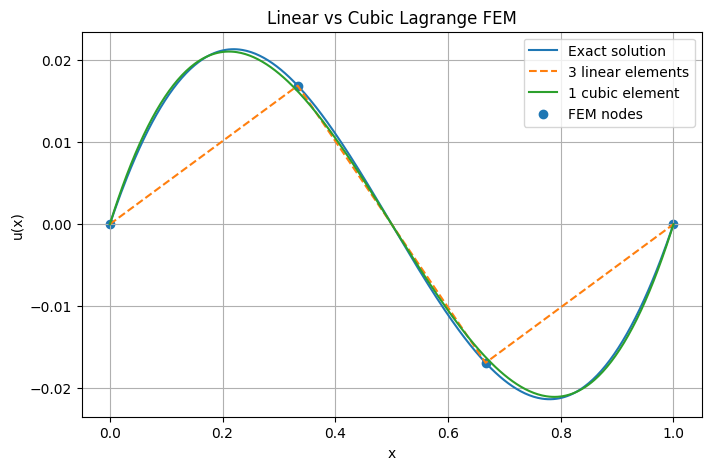

In [21]:

# Compare linear, cubic, and exact solution

x_plot = np.linspace(0,1,400)

u_cubic_plot = np.zeros_like(x_plot)

for i in range(4):
    u_cubic_plot += lagrange_basis(
        x_plot,cubic_nodes,i
    ) * U_cubic[i]

def u_exact(x):
    return (np.cos(np.pi*x) + 2*x - 1)/np.pi**2

plt.figure(figsize=(8,5))
plt.plot(x_plot,u_exact(x_plot),label="Exact solution")
plt.plot(x_linear_plot,u_linear_plot,"--",label="3 linear elements")
plt.plot(x_plot,u_cubic_plot,label="1 cubic element")
plt.scatter(nodes,U_linear,label="FEM nodes")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Linear vs Cubic Lagrange FEM")
plt.grid()
plt.legend()
plt.show()



# Problem 2: 1-D Heat Conduction

Solve

$$
-\frac{d}{dx}\left(kA\frac{dT}{dx}\right)=q'''A
$$

with

$$
L=0.30\ {\rm m},\quad
k=10\ {\rm W/(mK)},\quad
A=0.01\ {\rm m^2},
$$

$$
q'''=10000\ {\rm W/m^3},
\quad
T(0)=100^\circ{\rm C},
$$

and convection at $x=L$:

$$
-kA\frac{dT}{dx}=hA(T-T_\infty),
$$

where

$$
h=20\ {\rm W/(m^2K)},
\qquad
T_\infty=25^\circ{\rm C}.
$$


In [22]:

# Physical properties

L = 0.30
k = 10.0
A = 0.01
q = 10000.0
h = 20.0
T_inf = 25.0
T_left = 100.0

heat_nodes = np.linspace(0,L,4)

heat_connectivity = [
    [0,1],
    [1,2],
    [2,3]
]


In [23]:

# -----------------------------
# Three linear heat elements
# -----------------------------

K_heat = np.zeros((4,4))
F_heat = np.zeros(4)

for e in range(3):

    node1,node2 = heat_connectivity[e]

    x1 = heat_nodes[node1]
    x2 = heat_nodes[node2]

    local_nodes = [x1,x2]

    N = [
        sp.simplify(lagrange_basis(x,local_nodes,0)),
        sp.simplify(lagrange_basis(x,local_nodes,1))
    ]

    Ke = np.zeros((2,2))
    Fe = np.zeros(2)

    for i in range(2):

        for j in range(2):

            Ke[i,j] = float(
                sp.integrate(
                    k*A*sp.diff(N[i],x)*sp.diff(N[j],x),
                    (x,x1,x2)
                )
            )

        Fe[i] = float(
            sp.integrate(
                q*A*N[i],
                (x,x1,x2)
            )
        )

    print("\nElement",e+1)
    print("Ke =")
    print(Ke)
    print("Fe =")
    print(Fe)

    dofs = heat_connectivity[e]

    for i in range(2):

        I = dofs[i]
        F_heat[I] += Fe[i]

        for j in range(2):

            J = dofs[j]
            K_heat[I,J] += Ke[i,j]

    print("Global K after assembly:")
    print(K_heat)

print("\nGlobal heat K before convection:")
print(K_heat)

print("\nGlobal heat F before convection:")
print(F_heat)



Element 1
Ke =
[[ 1. -1.]
 [-1.  1.]]
Fe =
[5. 5.]
Global K after assembly:
[[ 1. -1.  0.  0.]
 [-1.  1.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]]

Element 2
Ke =
[[ 1. -1.]
 [-1.  1.]]
Fe =
[5. 5.]
Global K after assembly:
[[ 1. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  1.  0.]
 [ 0.  0.  0.  0.]]

Element 3
Ke =
[[ 1. -1.]
 [-1.  1.]]
Fe =
[5. 5.]
Global K after assembly:
[[ 1. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  1.]]

Global heat K before convection:
[[ 1. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  1.]]

Global heat F before convection:
[ 5. 10. 10.  5.]


In [24]:

# Add convection at x = L

K_heat[-1,-1] += h*A
F_heat[-1] += h*A*T_inf

print("Global heat K after convection:")
print(K_heat)

print("\nGlobal heat F after convection:")
print(F_heat)


Global heat K after convection:
[[ 1.  -1.   0.   0. ]
 [-1.   2.  -1.   0. ]
 [ 0.  -1.   2.  -1. ]
 [ 0.   0.  -1.   1.2]]

Global heat F after convection:
[ 5. 10. 10. 10.]


In [25]:

# -----------------------------
# Apply T1 = 100 C
# to the full 4x4 system
# -----------------------------

K_heat_bc = K_heat.copy()
F_heat_bc = F_heat.copy()

# Move known T1 contribution to RHS
F_heat_bc = F_heat_bc - K_heat_bc[:,0]*T_left

# Replace first equation by T1 = 100
K_heat_bc[0,:] = 0.0
K_heat_bc[:,0] = 0.0
K_heat_bc[0,0] = 1.0
F_heat_bc[0] = T_left

T_linear = np.linalg.solve(K_heat_bc,F_heat_bc)

print("Linear FEM temperatures:")
for i in range(4):
    print(
        f"Node {i+1}: "
        f"x = {heat_nodes[i]:.2f} m, "
        f"T = {T_linear[i]:.4f} C"
    )


Linear FEM temperatures:
Node 1: x = 0.00 m, T = 100.0000 C
Node 2: x = 0.10 m, T = 110.0000 C
Node 3: x = 0.20 m, T = 110.0000 C
Node 4: x = 0.30 m, T = 100.0000 C


In [12]:

# Reconstruct piecewise-linear temperature field

x_heat_linear = []
T_heat_linear = []

for e in range(3):

    xa = heat_nodes[e]
    xb = heat_nodes[e+1]

    xe = np.linspace(xa,xb,100)

    local_nodes = [xa,xb]

    N1 = lagrange_basis(xe,local_nodes,0)
    N2 = lagrange_basis(xe,local_nodes,1)

    Te = N1*T_linear[e] + N2*T_linear[e+1]

    x_heat_linear.extend(xe)
    T_heat_linear.extend(Te)

x_heat_linear = np.array(x_heat_linear)
T_heat_linear = np.array(T_heat_linear)



## One 4-node cubic heat-conduction element

The same four physical nodes are now used in one cubic element.


In [26]:

heat_cubic_nodes = heat_nodes.copy()

N_heat_cubic = []

for i in range(4):
    Ni = sp.simplify(
        lagrange_basis(x,heat_cubic_nodes,i)
    )
    N_heat_cubic.append(Ni)

    print(f"N{i+1}(x) =")
    sp.pprint(Ni)
    print()

K_heat_cubic = np.zeros((4,4))
F_heat_cubic = np.zeros(4)

for i in range(4):

    for j in range(4):

        K_heat_cubic[i,j] = float(
            sp.integrate(
                k*A*
                sp.diff(N_heat_cubic[i],x)*
                sp.diff(N_heat_cubic[j],x),
                (x,0,L)
            )
        )

    F_heat_cubic[i] = float(
        sp.integrate(
            q*A*N_heat_cubic[i],
            (x,0,L)
        )
    )

print("Cubic heat element/global K:")
print(K_heat_cubic)

print("\nCubic heat element/global F:")
print(F_heat_cubic)


N1(x) =
-16.6666666666667⋅(x - 0.3)⋅(x - 0.2)⋅(10.0⋅x - 1.0)

N2(x) =
500.0⋅x⋅(x - 0.3)⋅(x - 0.2)

N3(x) =
-500.0⋅x⋅(x - 0.3)⋅(x - 0.1)

N4(x) =
166.666666666667⋅x⋅(x - 0.2)⋅(x - 0.1)

Cubic heat element/global K:
[[ 1.23333333 -1.575       0.45       -0.10833333]
 [-1.575       3.6        -2.475       0.45      ]
 [ 0.45       -2.475       3.6        -1.575     ]
 [-0.10833333  0.45       -1.575       1.23333333]]

Cubic heat element/global F:
[ 3.75 11.25 11.25  3.75]


In [27]:

# Add convection

K_heat_cubic[-1,-1] += h*A
F_heat_cubic[-1] += h*A*T_inf

# Apply T1 = 100 C to full cubic 4x4 system

K_heat_cubic_bc = K_heat_cubic.copy()
F_heat_cubic_bc = F_heat_cubic.copy()

F_heat_cubic_bc = (
    F_heat_cubic_bc
    - K_heat_cubic_bc[:,0]*T_left
)

K_heat_cubic_bc[0,:] = 0.0
K_heat_cubic_bc[:,0] = 0.0
K_heat_cubic_bc[0,0] = 1.0
F_heat_cubic_bc[0] = T_left

T_cubic = np.linalg.solve(
    K_heat_cubic_bc,
    F_heat_cubic_bc
)

print("Cubic FEM temperatures:")
for i in range(4):
    print(
        f"Node {i+1}: "
        f"x = {heat_nodes[i]:.2f} m, "
        f"T = {T_cubic[i]:.4f} C"
    )


Cubic FEM temperatures:
Node 1: x = 0.00 m, T = 100.0000 C
Node 2: x = 0.10 m, T = 110.0000 C
Node 3: x = 0.20 m, T = 110.0000 C
Node 4: x = 0.30 m, T = 100.0000 C


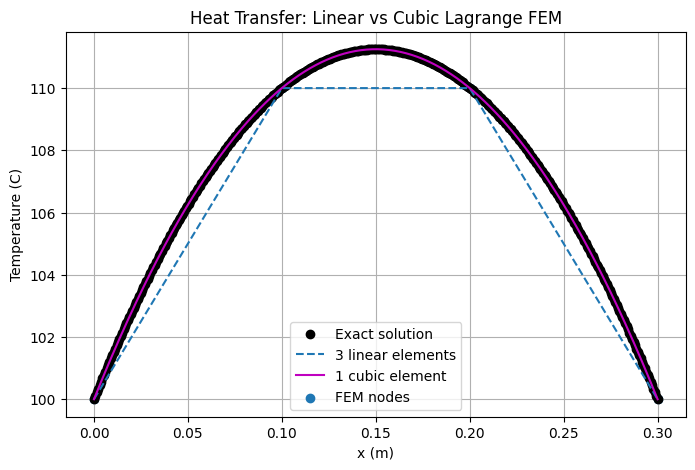

In [34]:

# Compare linear, cubic, and exact temperature distributions

x_heat_plot = np.linspace(0,L,400)

T_cubic_plot = np.zeros_like(x_heat_plot)

for i in range(4):

    T_cubic_plot += lagrange_basis(
        x_heat_plot,
        heat_cubic_nodes,
        i
    ) * T_cubic[i]

def T_exact(x):
    return -500.0*x**2 + 150.0*x + 100.0

plt.figure(figsize=(8,5))

plt.plot(
    x_heat_plot,
    T_exact(x_heat_plot),'ok',
    label="Exact solution"
)

plt.plot(
    x_heat_linear,
    T_heat_linear,
    "--",
    label="3 linear elements"
)

plt.plot(
    x_heat_plot,
    T_cubic_plot,'m',
    label="1 cubic element"
)

plt.scatter(
    heat_nodes,
    T_linear,
    label="FEM nodes"
)

plt.xlabel("x (m)")
plt.ylabel("Temperature (C)")
plt.title("Heat Transfer: Linear vs Cubic Lagrange FEM")
plt.grid()
plt.legend()
plt.show()
